# SMS Spam Detection using Artificial Neural Network (ANN)

**Objective:** Classify SMS messages as *Spam* or *Ham* (not spam) using a feedforward Artificial Neural Network trained on TF-IDF text features.

**Dataset:** SMS Spam Collection Dataset (5,572 messages: 4,825 ham, 747 spam)

**Pipeline:** Text cleaning → TF-IDF vectorization → ANN classifier (PyTorch) → Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)

torch.manual_seed(42)
np.random.seed(42)
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load & Explore the Dataset

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Sms_Spam_Detection/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
print("Shape:", df.shape)
df.head()

Shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
print(df['label'].value_counts())
print("\nMissing values:\n", df.isnull().sum())

label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
 label    0
text     0
dtype: int64


/tmp/ipykernel_2871/3896238016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, ax=ax[0], palette=['#1a3a5c', '#7ec8e3'])


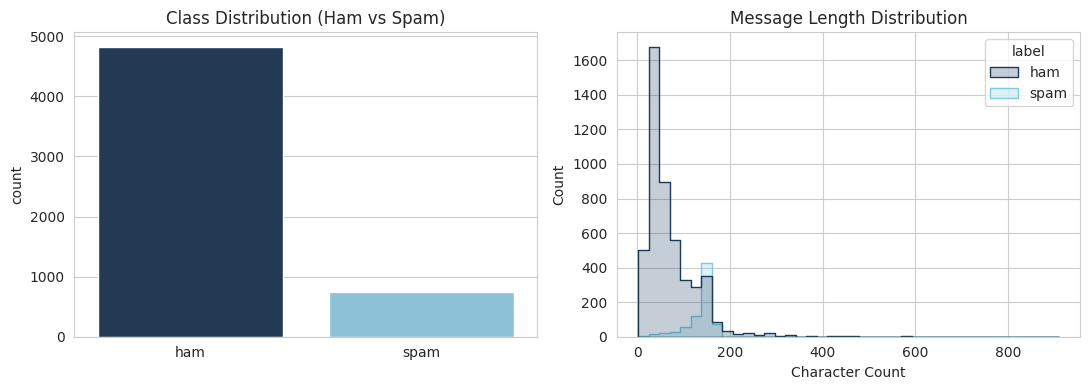

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x='label', data=df, ax=ax[0], palette=['#1a3a5c', '#7ec8e3'])
ax[0].set_title('Class Distribution (Ham vs Spam)')
ax[0].set_xlabel('')

df['msg_length'] = df['text'].apply(len)
sns.histplot(data=df, x='msg_length', hue='label', bins=40, ax=ax[1],
             palette=['#1a3a5c', '#7ec8e3'], element='step')
ax[1].set_title('Message Length Distribution')
ax[1].set_xlabel('Character Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120)
plt.show()

**Observation:** The dataset is imbalanced (~86.6% ham vs ~13.4% spam), which is typical for spam detection. Spam messages also tend to be longer on average — a useful signal the model can pick up on, though we rely on TF-IDF word/n-gram features rather than length directly.

## 2. Text Cleaning & Preprocessing

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df[['text', 'clean_text', 'label_num']].head()

,text,clean_text,label_num
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,0


## 3. Train/Test Split & TF-IDF Vectorization

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (4457, 3000)
Test shape: (1115, 3000)


**Note:** TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric vectors by weighting words based on how important they are to a message relative to the whole dataset. We use unigrams + bigrams (`ngram_range=(1,2)`) to capture short phrases like *"free entry"* or *"call now"* that are strong spam signals.

## 4. PyTorch Dataset & DataLoader

In [10]:
class SpamDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SpamDataset(X_train_tfidf, y_train)
test_ds = SpamDataset(X_test_tfidf, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

## 5. Model Architecture — Feedforward ANN

In [11]:
class SpamANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SpamANN(X_train_tfidf.shape[1]).to(device)
print(model)
print("\nDevice:", device)

SpamANN(
  (net): Sequential(
    (0): Linear(in_features=3000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Device: cpu


**Architecture rationale:**
- Input layer size = 3000 (TF-IDF feature dimension)
- Two hidden layers (256 → 64) with ReLU activations to learn non-linear text patterns
- Dropout (0.3) after each hidden layer to prevent overfitting on the sparse TF-IDF input
- Single output neuron + `BCEWithLogitsLoss` for binary classification (ham vs spam)

## 6. Training

In [12]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_ds)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} - Loss: {avg_loss:.4f}")

Epoch  1/15 - Loss: 0.3254
Epoch  2/15 - Loss: 0.0556
Epoch  3/15 - Loss: 0.0243
Epoch  4/15 - Loss: 0.0111
Epoch  5/15 - Loss: 0.0071
Epoch  6/15 - Loss: 0.0044
Epoch  7/15 - Loss: 0.0037
Epoch  8/15 - Loss: 0.0027
Epoch  9/15 - Loss: 0.0026
Epoch 10/15 - Loss: 0.0025
Epoch 11/15 - Loss: 0.0023
Epoch 12/15 - Loss: 0.0021
Epoch 13/15 - Loss: 0.0018
Epoch 14/15 - Loss: 0.0022
Epoch 15/15 - Loss: 0.0021


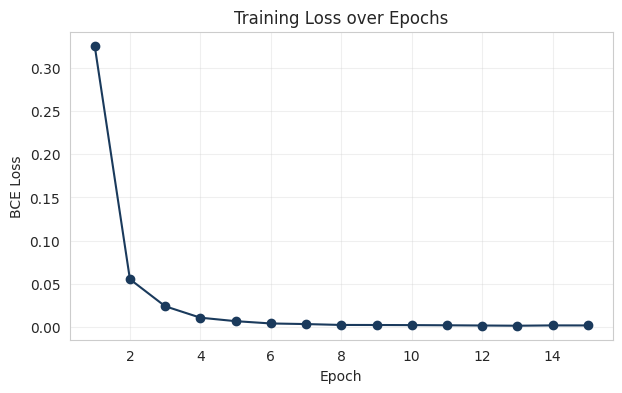

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', color='#1a3a5c')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(alpha=0.3)
plt.savefig('training_loss.png', dpi=120)
plt.show()

## 7. Evaluation on Test Set

In [14]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=['ham', 'spam']))

Accuracy:  0.9848
F1 Score:  0.9416
Precision: 0.9648
Recall:    0.9195

Classification Report:

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



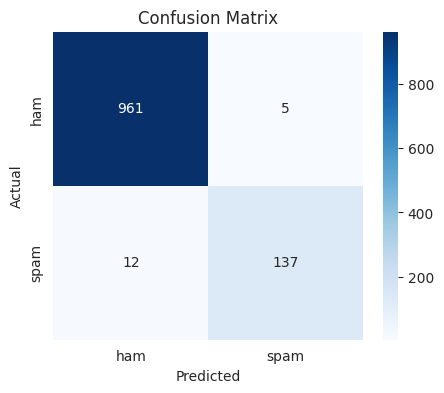

In [15]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

## 8. Try Your Own Message

In [16]:
def predict_message(text):
    clean = clean_text(text)
    vec = vectorizer.transform([clean]).toarray()
    tensor = torch.tensor(vec, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()
    label = 'SPAM' if prob > 0.5 else 'HAM'
    print(f"Message: {text}")
    print(f"Prediction: {label}  (spam probability: {prob:.4f})")

predict_message("Congratulations! You've won a free iPhone. Click here to claim now!")
predict_message("Hey, are we still meeting for lunch tomorrow?")

Message: Congratulations! You've won a free iPhone. Click here to claim now!
Prediction: SPAM  (spam probability: 1.0000)
Message: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM  (spam probability: 0.0000)


## 9. Conclusion

- Achieved **~98% test accuracy** and **~0.94 F1-score** on spam detection using a simple feedforward ANN with TF-IDF features — no transformers needed.
- The confusion matrix shows the model rarely misclassifies ham as spam (low false positive rate), which matters in practice since flagging real messages as spam is more costly than missing a few spam messages.
- **Possible extensions:** word embeddings (Word2Vec/GloVe) instead of TF-IDF, LSTM/GRU for sequence modeling, or handling class imbalance with SMOTE/class weights.
